In [19]:
import os 
os.chdir("../SPID_code")

print(os.getcwd())

c:\GitHub\GGSpeciale\code\SPID_code


In [20]:
import socket

print("Host:", socket.gethostname())
print("SLURM job:", os.environ.get("SLURM_JOB_ID"))

Host: SofiesPC
SLURM job: None


In [21]:
from importlib import reload
#import gmDAGGER
#reload(gmDAGGER)
from gmDAGGER import train_spid


from stable_baselines3 import PPO, DDPG, SAC, TD3

from baseline_code.baseline_enviroments.cartpole_env import ContinuousCartPoleEnv

In [22]:
#import PySRWrapper
#reload(PySRWrapper)
from PySRWrapper import PySRPolicy
from stable_baselines3.common.env_util import make_vec_env

env = make_vec_env("MountainCarContinuous-v0", n_envs=1, env_kwargs={})
policy = PySRPolicy(env)

In [23]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You are trying to run PPO on the GPU"
)

warnings.filterwarnings(
    "ignore",
    message="Note: it looks like you are running in Jupyter"
)

# example

# rewards, best_policy, wrapper, run_dir = train_spid(r"/home/ashc/GGSpeciale/ashc_repo/GGSpeciale/code/baseline_code/baseline_models/cartpole/PPO_cartpole.zip", PPO, "", "CartPole-v1", n_iter=1, total_timesteps=3, verbose=2)

teacher_model_path = r"C:\GitHub\GGSpeciale\code\baseline_code\baseline_models\swimmer\PPO_swimmer.zip"
teacher_model = PPO
environment ="Swimmer-v5" # ContinuousCartPoleEnv #"Swimmer-v5" # or use string like CartPole-v1

# rewards, best_policy, wrapper, run_dir = train_spid(teacher_path = teacher_model_path, 
#                                                     teacher_model = teacher_model, 
#                                                     save_folder_path="code/SPID_code/swimmer_v5_PPO", 
#                                                     save_results=True, 
#                                                     environment=environment, 
#                                                     n_iter=10, 
#                                                     total_timesteps=10*50, 
#                                                     n_eval_episodes=10,
#                                                     verbose=2)

In [25]:
rewards, best_policy, best_wrapper, run_dir = train_spid(
    teacher_path=None,                 # no local checkpoint
    teacher_model=None,                # SB3 class
    save_folder_path="MountainCarContinuous_models/MountainCarContinuous-v0-TRPO",
    environment="MountainCarContinuous-v0",         # must match the teacher checkpoint env
    n_iter=10,
    total_timesteps=10*200,
    save_results=True,
    verbose=2,
    n_eval_episodes=20,
    final_n_val_episodes=100,
    hf_repo_id="sb3/trpo-MountainCarContinuous-v0",
    hf_filename="trpo-MountainCarContinuous-v0.zip",
    hf_algo="trpo",
    vecnormalize_path="vec_normalize.pkl"
)

Loading normalized env from Hugging Face
Loaded Hugging Face teacher from: sb3/trpo-MountainCarContinuous-v0/trpo-MountainCarContinuous-v0.zip
finished collecting trajectories
computing advantages
Loading normalized env from Hugging Face
training
Evaluating trained model
Loading normalized env from Hugging Face
Iteration 0: student reward = 91.8488 +/- 0.6965
Loading normalized env from Hugging Face
Loaded Hugging Face teacher from: sb3/trpo-MountainCarContinuous-v0/trpo-MountainCarContinuous-v0.zip
finished collecting trajectories
computing advantages
Loading normalized env from Hugging Face
training
Evaluating trained model
Loading normalized env from Hugging Face
Iteration 1: student reward = 92.6542 +/- 0.4529
Loading normalized env from Hugging Face
Loaded Hugging Face teacher from: sb3/trpo-MountainCarContinuous-v0/trpo-MountainCarContinuous-v0.zip
finished collecting trajectories
computing advantages
Loading normalized env from Hugging Face
training
Evaluating trained model
Load

In [ ]:
from SPID_code.PySRWrapper import PySRWrapper
# best_policy = PySRWrapper.load("/home/ashc/GGSpeciale/ashc_repo/GGSpeciale/code/best_student_policy.joblib")

In [ ]:
print(best_policy)

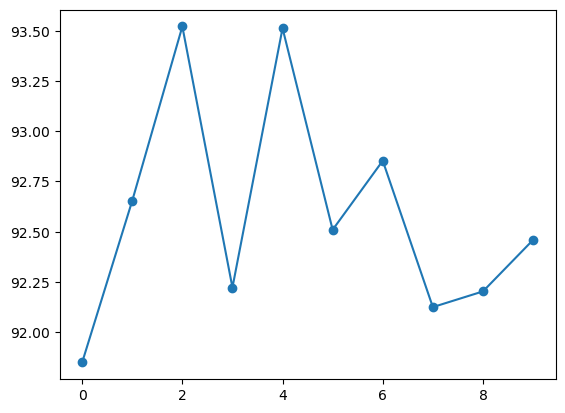

In [26]:
import matplotlib.pyplot as plt

plt.plot(range(len(rewards)), rewards)
plt.scatter(range(len(rewards)), rewards)

# Test Huggin Face pre-trained model

In [ ]:
# pip install "stable-baselines3[extra]" huggingface-sb3 gymnasium[classic-control]

from huggingface_sb3 import load_from_hub
from stable_baselines3 import SAC, DDPG
from sb3_contrib import TRPO
from stable_baselines3.common.evaluation import evaluate_policy
import gymnasium as gym

# Hugging Face repo + model file
repo_id = "farama-minari/Reacher-v5-SAC-medium"
filename = "reacher-v5-SAC-medium.zip"

# Download model
checkpoint_path = load_from_hub(repo_id=repo_id, filename=filename)

# Load model
model = SAC.load(checkpoint_path)

# Create environment
env = gym.make("Reacher-v5")

# Evaluate the policy
mean_reward, std_reward = evaluate_policy(
    model,
    env,
    n_eval_episodes=10,
    deterministic=True
)

print(f"Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

env.close()

c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean reward: -3.84 +/- 1.63


# Test Hugging Face pre-trained model (with normalization)

In [ ]:
from huggingface_hub import hf_hub_download
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import gymnasium as gym

repo_id = "sb3/ppo-MountainCarContinuous-v0"
model_path = hf_hub_download(repo_id=repo_id, filename="ppo-MountainCarContinuous-v0.zip")
vecnorm_path = hf_hub_download(repo_id=repo_id, filename="vec_normalize.pkl")

def make_env():
    return Monitor(gym.make("MountainCarContinuous-v0"))

vec_env = DummyVecEnv([make_env])
vec_env = VecNormalize.load(vecnorm_path, vec_env)
vec_env.training = False
vec_env.norm_reward = False

# Load WITHOUT env to avoid space-class mismatch check
model = PPO.load(model_path)

mean_reward, std_reward = evaluate_policy(
    model,
    vec_env,
    n_eval_episodes=100,
    deterministic=True,
)

print(f"Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

vec_env.close()

Mean reward: 94.01 +/- 0.98
